In [11]:
import joblib
import os
import pandas as pd
from mapie.regression.regression import _MapieRegressor as MapieRegressor
from sklearn.model_selection import train_test_split

In [17]:
root_path = os.path.dirname(os.getcwd())

models_path = os.path.join(root_path, 'models')
best_ebm = joblib.load(os.path.join(models_path, 'fitted_ebm_final.pkl'))

cleaned_data_path = os.path.join(root_path, "datasets/cleaned")
X_train = pd.read_csv(os.path.join(cleaned_data_path, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(cleaned_data_path, 'y_train.csv'))
X_test = pd.read_csv(os.path.join(cleaned_data_path, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(cleaned_data_path, 'y_test.csv'))

In [19]:
mapie = MapieRegressor(estimator=best_ebm, cv="prefit")
mapie.fit(X_train, y_train.values.ravel())

y_preds, y_pis = mapie.predict(X_test, alpha=0.1)

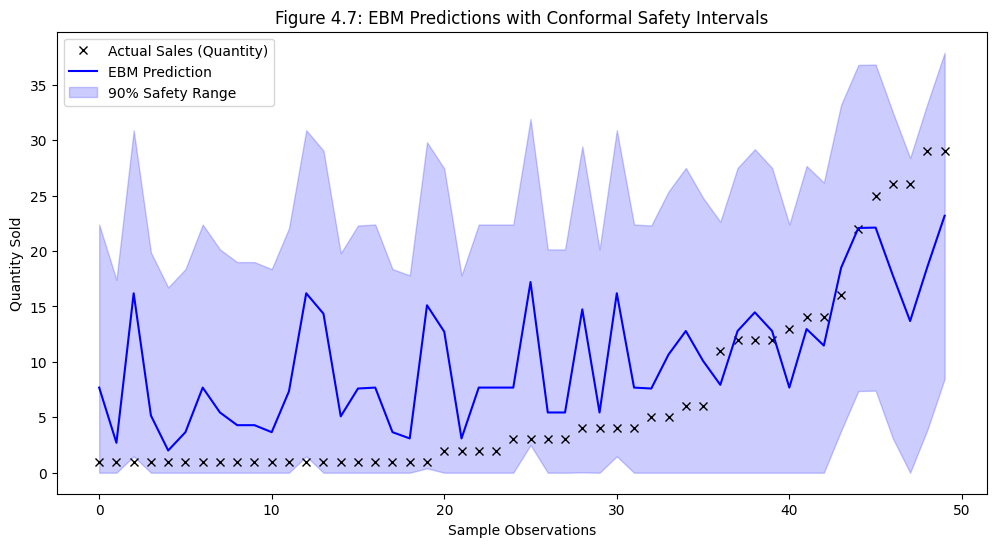

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Sorting for a cleaner visualization (taking a sample of 50 points)
indices = np.argsort(y_test.values.ravel()[:50])
y_test_plot = y_test.values.ravel()[:50][indices]
y_preds_plot = y_preds[:50][indices]
lower_bound = y_pis[:50, 0, 0][indices]
upper_bound = y_pis[:50, 1, 0][indices]
lower_bound_clipped = np.maximum(0, lower_bound)

plt.figure(figsize=(12, 6))
plt.plot(y_test_plot, 'kx', label="Actual Sales (Quantity)")
plt.plot(y_preds_plot, 'b-', label="EBM Prediction")
plt.fill_between(range(len(y_test_plot)), lower_bound_clipped, upper_bound, color='b', alpha=0.2, label="90% Safety Range")
plt.title("Figure 4.7: EBM Predictions with Conformal Safety Intervals")
plt.xlabel("Sample Observations")
plt.ylabel("Quantity Sold")
plt.legend()
plt.show()